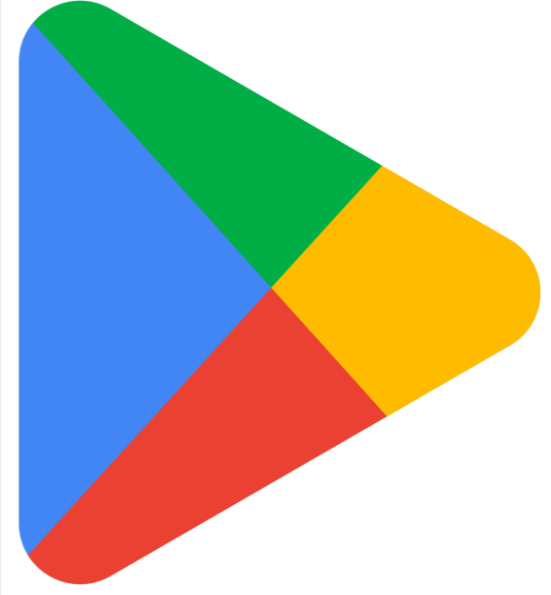

## Google Play Store App Performance Analysis: Insights into Installs, Ratings, and Market Trends

### Overview

The Google Play Store ecosystem is highly competitive and heavily dominated by a small number of app categories, particularly Games, Communication, and Tools. App success is driven more by category popularity and visibility than by ratings or pricing, with free apps significantly outperforming paid ones in terms of installs. While most apps receive generally positive ratings, user engagement and installs are highly skewed, with a small number of apps accounting for the majority of downloads.

#### Summary of Findings
This analysis examined what makes apps successful on the Google Play Store, using installs, ratings, reviews, pricing, and categories.

We found that a small number of categories contain most of the popular apps. Games and Communication apps lead in installs, while other categories have much lower usage.

Most apps are rated positively, but high ratings do not always mean high installs. This shows that being well-rated is not enough for success.

We also saw that free apps perform much better than paid apps in terms of installs, showing that users strongly prefer free content.

Installs and reviews are highly uneven, with a few apps getting most of the attention while many remain less popular.

#### Story Framing (What the Data Tells Us)
Overall, the data shows that success in the Google Play Store depends more on category and visibility than on price or ratings. A few popular apps and categories attract most of the users, while the majority of apps get only a small share of attention.

### Business Understanding
#### Purpose of the Analysis

This analysis explores the factors driving app success on the Google Play Store, focusing on installs, ratings, reviews, pricing, and category performance. The goal is to understand why some apps become highly popular while others remain less visible.

#### Why These Findings are Important

The app market is highly competitive, and small differences in visibility, pricing, or category can significantly affect performance. Understanding these patterns helps explain user behavior and the factors that influence app success.

#### Stakeholders

This analysis is useful for:

App developers
Product managers
Marketing teams
Business decision-makers in mobile platforms

They can use these insights to improve app design, positioning, and growth strategy.

#### Key Questions this Analysis Should Answer

This analysis aims to answer:

What factors drive app installs and popularity?
Do ratings influence app success?
Which categories perform best in the market?
Do free apps outperform paid apps?
How does user engagement (reviews) relate to installs?

### Data Understanding
#### Data Source

The dataset comes from Google Play Store app listings, containing information about mobile applications such as category, rating, installs, reviews, pricing, and technical details.

#### What the Data Contains

The dataset includes key fields such as:

App name
Category and genre
Rating and reviews
Number of installs
App size
Price
Content rating
Android version requirements
Last updated date

These fields help describe both app performance and technical characteristics.

#### Relevant vs Irrelevant Data

Most fields are useful for understanding app performance and user behavior. However, some values were inconsistent or not directly useful for analysis in their raw form, such as mixed-format text entries and incorrectly formatted numerical fields.

Key focus areas for analysis were:

Ratings
Installs
Reviews
Category/Genre
Price

#### Data Quality Issues Identified

Several issues were found during exploration:

Null values in key columns, such as ratings and versions
Type mismatches, where numbers were stored as text (e.g., installs, price, reviews)
Inconsistent formats, such as “10,000+” or “Varies with device”
Invalid entries, including unexpected text values in numeric or categorical fields
Duplicate or inconsistent category/genre labels

#### Data Cleaning Required

To prepare the dataset for analysis, the following steps were necessary:

Converting text-based numeric fields into proper numeric types
Removing symbols such as “+”, “$”, and commas from values
Handling missing and invalid values
Standardizing category and genre labels
Creating consistent formats for size, installs, and version fields

### Summary

Overall, the dataset required moderate cleaning to ensure consistency and accuracy. Once cleaned, it became suitable for exploratory analysis and visualization to uncover trends in app performance and user behavior.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark import SparkContext
from pyspark.sql import SparkSession

In [28]:
spark = SparkSession.builder.master('local').getOrCreate()
spark.sparkContext.setLogLevel("WARN")

In [29]:
import os
os.getcwd()

'/home/jovyan/work/Desktop/DSFTTR_FILES'

In [30]:
import os
os.listdir("/home/jovyan/work/Desktop")

['.ipynb_checkpoints',
 '.virtual_documents',
 'cleaned_google_play_store_dataset.csv',
 'desktop.ini',
 'Docker Desktop.lnk',
 'DSFTTR_FILES',
 'Google Chrome.lnk',
 'google_play_store_dataset.csv',
 'Untitled.ipynb',
 'untitled.py',
 'Untitled1.ipynb',
 'Untitled2.ipynb']

In [31]:
os.listdir("/home/jovyan/work/Desktop")


['.ipynb_checkpoints',
 '.virtual_documents',
 'cleaned_google_play_store_dataset.csv',
 'desktop.ini',
 'Docker Desktop.lnk',
 'DSFTTR_FILES',
 'Google Chrome.lnk',
 'google_play_store_dataset.csv',
 'Untitled.ipynb',
 'untitled.py',
 'Untitled1.ipynb',
 'Untitled2.ipynb']

### Loading the and understanding the dataset

In [116]:
spark_df = spark.read.csv(
    "/home/jovyan/work/Desktop/google_play_store_dataset.csv",
    header=True,
    inferSchema=True
)

In [117]:
spark_df.show(5)

+--------------------+--------------+------+-------+----+-----------+----+-----+--------------+--------------------+----------------+------------------+------------+
|                 App|      Category|Rating|Reviews|Size|   Installs|Type|Price|Content Rating|              Genres|    Last Updated|       Current Ver| Android Ver|
+--------------------+--------------+------+-------+----+-----------+----+-----+--------------+--------------------+----------------+------------------+------------+
|Photo Editor & Ca...|ART_AND_DESIGN|   4.1|    159| 19M|    10,000+|Free|    0|      Everyone|        Art & Design| January 7, 2018|             1.0.0|4.0.3 and up|
| Coloring book moana|ART_AND_DESIGN|   3.9|    967| 14M|   500,000+|Free|    0|      Everyone|Art & Design;Pret...|January 15, 2018|             2.0.0|4.0.3 and up|
|U Launcher Lite –...|ART_AND_DESIGN|   4.7|  87510|8.7M| 5,000,000+|Free|    0|      Everyone|        Art & Design|  August 1, 2018|             1.2.4|4.0.3 and up|
|Ske

In [118]:
spark_df.printSchema()

root
 |-- App: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Rating: string (nullable = true)
 |-- Reviews: string (nullable = true)
 |-- Size: string (nullable = true)
 |-- Installs: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- Content Rating: string (nullable = true)
 |-- Genres: string (nullable = true)
 |-- Last Updated: string (nullable = true)
 |-- Current Ver: string (nullable = true)
 |-- Android Ver: string (nullable = true)



### Dealing with trailing spaces and lowercases in column names

In [119]:
# Fixingtrailing spaces and lowercases
spark_df = spark_df.toDF(
    *[c.strip().lower().replace(" ", "_") for c in spark_df.columns]
)
#df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
spark_df.printSchema()

root
 |-- app: string (nullable = true)
 |-- category: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- reviews: string (nullable = true)
 |-- size: string (nullable = true)
 |-- installs: string (nullable = true)
 |-- type: string (nullable = true)
 |-- price: string (nullable = true)
 |-- content_rating: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- last_updated: string (nullable = true)
 |-- current_ver: string (nullable = true)
 |-- android_ver: string (nullable = true)



### Converting the dataset to pandas dataframe for easier imputation

In [120]:
#converting the dataset to pandas dataframe
google_pdf =spark_df.toPandas()
google_pdf.describe()

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
count,10841,10841,10841,10841,10841,10841,10841,10841,10840,10841,10841,10840,10840
unique,9660,36,43,6002,464,24,6,95,8,121,1379,2835,36
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,1474,596,1694,1578,10037,10038,8713,842,326,1458,2450


## Exploratory Data Analysis

In [121]:
# checking the unique columns 
for col in google_pdf.columns:
    uniques=google_pdf[col].unique()
    print(col)
    print(uniques)

app
['Photo Editor & Candy Camera & Grid & ScrapBook' 'Coloring book moana'
 'U Launcher Lite – FREE Live Cool Themes, Hide Apps' ...
 'Parkinson Exercices FR' 'The SCP Foundation DB fr nn5n'
 'iHoroscope - 2018 Daily Horoscope & Astrology']
category
['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' ' traffic jams' 'Face' '1.9']
rating
['4.1' '3.9' '4.7' '4.5' '4.3' '4.4' '3.8' '4.2' '4.6' '3.2' '4.0' 'NaN'
 '4.8' '4.9' '3.6' '3.7' '3.3' '3.4' '3.5' '3.1' '5.0' '2.6' '3.0' '1.9'
 '2.5' '2.8' '2.7' '1.0' '2.9' '2.3' ' navigation' '2.2' '1.7' '2.0' '1.8'
 '2.4' '1.6' '2.1' '1.4' '

### Cleaning the columns one by one

In [122]:
# cleaning the categorical column
google_pdf["category"] = google_pdf["category"].str.lower().str.strip()

import re

google_pdf = google_pdf[google_pdf["category"].str.contains(r"^[a-z_& ]+$", na=False)]
google_pdf["category"].unique()

array(['art_and_design', 'auto_and_vehicles', 'beauty',
       'books_and_reference', 'business', 'comics', 'communication',
       'dating', 'education', 'entertainment', 'events', 'finance',
       'food_and_drink', 'health_and_fitness', 'house_and_home',
       'libraries_and_demo', 'lifestyle', 'game', 'family', 'medical',
       'social', 'shopping', 'photography', 'sports', 'travel_and_local',
       'tools', 'personalization', 'productivity', 'parenting', 'weather',
       'video_players', 'news_and_magazines', 'maps_and_navigation',
       'traffic jams', 'face'], dtype=object)

In [123]:
# cleaning the ratings column
google_pdf["rating"] = pd.to_numeric(google_pdf["rating"], errors="coerce")
google_pdf.loc[
    (google_pdf["rating"] < 1) | (google_pdf["rating"] > 5),
    "rating"
] = pd.NA
google_pdf["rating"].dtype
google_pdf["rating"].unique()

array([4.1, 3.9, 4.7, 4.5, 4.3, 4.4, 3.8, 4.2, 4.6, 3.2, 4. , nan, 4.8,
       4.9, 3.6, 3.7, 3.3, 3.4, 3.5, 3.1, 5. , 2.6, 3. , 1.9, 2.5, 2.8,
       2.7, 1. , 2.9, 2.3, 2.2, 1.7, 2. , 1.8, 2.4, 1.6, 2.1, 1.4, 1.5,
       1.2])

In [124]:
# using the mean to fill the nans
google_pdf["rating"] = google_pdf["rating"].fillna(google_pdf["rating"].mean())
google_pdf["rating"] = google_pdf["rating"].round(2)
google_pdf["rating"].unique()

array([4.1 , 3.9 , 4.7 , 4.5 , 4.3 , 4.4 , 3.8 , 4.2 , 4.6 , 3.2 , 4.  ,
       4.19, 4.8 , 4.9 , 3.6 , 3.7 , 3.3 , 3.4 , 3.5 , 3.1 , 5.  , 2.6 ,
       3.  , 1.9 , 2.5 , 2.8 , 2.7 , 1.  , 2.9 , 2.3 , 2.2 , 1.7 , 2.  ,
       1.8 , 2.4 , 1.6 , 2.1 , 1.4 , 1.5 , 1.2 ])

In [125]:
#working on the reviews column
google_pdf["reviews"] = pd.to_numeric(google_pdf["reviews"], errors="coerce")
google_pdf["reviews"] = google_pdf["reviews"].fillna(google_pdf["reviews"].median()).astype(int)

In [126]:
google_pdf.loc[
    pd.to_numeric(google_pdf["reviews"], errors="coerce").isna(),
    "reviews"
].unique()

array([], dtype=int64)

In [127]:
google_pdf["reviews"] = pd.to_numeric(google_pdf["reviews"]).astype(int)
google_pdf[
    google_pdf["reviews"].astype(str).str.match(r"^\d+$", na=False)
].shape

(10840, 13)

In [128]:
#cleaning the sizes column
# lets start with invalid entries
invalid_entries = [
    "MAPS_AND_NAVIGATION",
    "HEALTH_AND_FITNESS"
]
google_pdf["size"] = google_pdf["size"].replace("Varies with device", np.nan)
google_pdf["size"] = google_pdf["size"].replace(invalid_entries, np.nan)
google_pdf["size_mb"] = google_pdf["size"].apply(convert_size)

In [129]:
#converting the K and M to numeric MB

def convert_size(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip()

    if x.endswith("M"):
        return float(x.replace("M", ""))
    
    if x.endswith("k"):
        return float(x.replace("k", "")) / 1024
    
    return np.nan
google_pdf["size_mb"] = google_pdf["size"].apply(convert_size)
sorted(google_pdf["size"].dropna().unique())[:10]


['1.0M',
 '1.1M',
 '1.2M',
 '1.3M',
 '1.4M',
 '1.5M',
 '1.6M',
 '1.7M',
 '1.8M',
 '1.9M']

In [130]:
#fixing the installs column
#removing spaces
google_pdf["installs"] = google_pdf["installs"].astype(str).str.strip()

#removing invalid values
invalid_installs = ["Free"]

google_pdf["installs"] = google_pdf["installs"].replace(invalid_installs, np.nan)
#removing comas and plus signs

google_pdf["installs"] = google_pdf["installs"].str.replace(",", "", regex=False)
google_pdf["installs"] = google_pdf["installs"].str.replace("+", "", regex=False)

#removing the leaked rating values
google_pdf = google_pdf[
    google_pdf["installs"].str.match(r"^\d+$", na=False)
]
# converting to intergers
google_pdf["installs"] = google_pdf["installs"].astype(int)
google_pdf["installs"] = google_pdf["installs"].fillna(google_pdf["installs"].median())

google_pdf["installs"].describe()

count    1.083800e+04
mean     1.546664e+07
std      8.503703e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      5.000000e+06
max      1.000000e+09
Name: installs, dtype: float64

In [131]:
# cleaning the price column
google_pdf["price"] = google_pdf["price"].astype(str).str.strip()
google_pdf["price"] = google_pdf["price"].replace(
    ["Free", "Varies with device"],
    "0"
)
google_pdf["price"] = google_pdf["price"].replace(
    ["Free", "Varies with device"],
    "0"
)
#emoving the dollar sign
google_pdf["price"] = google_pdf["price"].str.replace("$", "", regex=False)
#converting to numeric
google_pdf["price"] = pd.to_numeric(google_pdf["price"], errors="coerce")
google_pdf["price"] = google_pdf["price"].fillna(0)
google_pdf["price"].describe()

count    10838.000000
mean         1.027558
std         15.951169
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        400.000000
Name: price, dtype: float64

In [132]:
google_pdf["price"].value_counts().head(10)

price
0.00    10038
0.99      148
2.99      129
1.99       73
4.99       72
3.99       63
1.49       46
5.99       30
2.49       26
9.99       21
Name: count, dtype: int64

In [133]:
# fixing the content rating column
google_pdf["content_rating"] = google_pdf["content_rating"].astype(str).str.strip()
google_pdf["content_rating"] = google_pdf["content_rating"].replace(
    ["None", "nan", "NaN"],
    np.nan
)
bad_leaks = ["5,000,000+", "1,000,000+"]

google_pdf["content_rating"] = google_pdf["content_rating"].replace(bad_leaks, np.nan)
google_pdf["content_rating"].value_counts(dropna=False)

content_rating
Everyone           8713
Teen               1208
Mature 17+          498
Everyone 10+        414
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

In [134]:
google_pdf["content_rating"].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated'], dtype=object)

In [135]:
google_pdf.columns


Index(['app', 'category', 'rating', 'reviews', 'size', 'installs', 'type',
       'price', 'content_rating', 'genres', 'last_updated', 'current_ver',
       'android_ver', 'size_mb'],
      dtype='object')

In [137]:
#cleaning the genre column
google_pdf["genres"] = google_pdf["genres"].astype(str).str.strip()
genre_split = google_pdf["genres"].str.split(";", expand=True)

invalid_genres = ["Free", "February 11, 2018"]
google_pdf["genres"] = google_pdf["genres"].replace(invalid_genres, np.nan)

google_pdf["primary_genre"] = genre_split[0]
google_pdf["secondary_genre"] = genre_split[1]

google_pdf["primary_genre"] = google_pdf["primary_genre"].str.strip()
google_pdf["secondary_genre"] = google_pdf["secondary_genre"].str.strip()
google_pdf["genres"].value_counts()


genres
Tools                                842
Entertainment                        623
Education                            549
Medical                              463
Business                             460
                                    ... 
Parenting;Brain Games                  1
Travel & Local;Action & Adventure      1
Lifestyle;Pretend Play                 1
Tools;Education                        1
Strategy;Creativity                    1
Name: count, Length: 119, dtype: int64

In [139]:
google_pdf[["genres"]].tail(20)

,genres
10821,Entertainment
10822,Productivity
10823,Video Players & Editors
10824,Medical
10825,Social
10826,Social
10827,Education
10828,Comics
10829,Books & Reference
10830,News & Magazines


In [141]:
# converting the last updated column to a proper datetime
google_pdf["last_updated"] = pd.to_datetime(
    google_pdf["last_updated"],
    errors="coerce"
)
google_pdf["last_updated"].dtype

dtype('<M8[ns]')

In [144]:
google_pdf["last_updated"].isnull().sum()

0

In [147]:
#cleaning the invalid values in the current ver column
invalid_values = [
    "Varies with device",
    "NaN",
    "nan",
    "None"
]
google_pdf["current_ver"] = google_pdf["current_ver"].replace(invalid_values, np.nan)

In [148]:
# cleaning the invalid values in android version column
invalid_values = [
    "Varies with device",
    "NaN",
    "None",
    "Maps & Navigation",
    "Health & Fitness"
]

google_pdf["android_ver"] = google_pdf["android_ver"].replace(invalid_values, np.nan)

In [152]:
google_pdf.describe()

,rating,reviews,installs,price,last_updated,size_mb
count,10838.000000,1.083800e+04,1.083800e+04,10838.000000,10838,9144.000000
mean,4.191498,4.442252e+05,1.546664e+07,1.027558,2017-11-21 05:49:34.201882112,21.517972
min,1.000000,0.000000e+00,0.000000e+00,0.000000,2010-05-21 00:00:00,0.008301
25%,4.100000,3.800000e+01,1.000000e+03,0.000000,2017-09-20 00:00:00,4.900000
50%,4.200000,2.093500e+03,1.000000e+05,0.000000,2018-05-24 00:00:00,13.000000
75%,4.500000,5.470600e+04,5.000000e+06,0.000000,2018-07-20 00:00:00,30.000000
max,5.000000,7.815831e+07,1.000000e+09,400.000000,2018-08-08 00:00:00,100.000000
std,0.478947,2.928026e+06,8.503703e+07,15.951169,NaN,22.589659


### Validation checks for cleaned data

In [159]:
google_pdf.head(10)

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver,size_mb,primary_genre,secondary_genre
0,Photo Editor & Candy Camera & Grid & ScrapBook,art_and_design,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0,Art & Design,None
1,Coloring book moana,art_and_design,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0,Art & Design,Pretend Play
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",art_and_design,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7,Art & Design,None
3,Sketch - Draw & Paint,art_and_design,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,2018-06-08,NaN,4.2 and up,25.0,Art & Design,None
4,Pixel Draw - Number Art Coloring Book,art_and_design,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8,Art & Design,Creativity
5,Paper flowers instructions,art_and_design,4.4,167,5.6M,50000,Free,0.0,Everyone,Art & Design,2017-03-26,1.0,2.3 and up,5.6,Art & Design,None
6,Smoke Effect Photo Maker - Smoke Editor,art_and_design,3.8,178,19M,50000,Free,0.0,Everyone,Art & Design,2018-04-26,1.1,4.0.3 and up,19.0,Art & Design,None
7,Infinite Painter,art_and_design,4.1,36815,29M,1000000,Free,0.0,Everyone,Art & Design,2018-06-14,6.1.61.1,4.2 and up,29.0,Art & Design,None
8,Garden Coloring Book,art_and_design,4.4,13791,33M,1000000,Free,0.0,Everyone,Art & Design,2017-09-20,2.9.2,3.0 and up,33.0,Art & Design,None
9,Kids Paint Free - Drawing Fun,art_and_design,4.7,121,3.1M,10000,Free,0.0,Everyone,Art & Design;Creativity,2018-07-03,2.8,4.0.3 and up,3.1,Art & Design,Creativity


In [161]:
### Analyzing the value distributions and patterns
# Starting with the numerical values\
google_pdf[["reviews", "installs", "price"]].describe()

,reviews,installs,price
count,1.083800e+04,1.083800e+04,10838.000000
mean,4.442252e+05,1.546664e+07,1.027558
std,2.928026e+06,8.503703e+07,15.951169
min,0.000000e+00,0.000000e+00,0.000000
25%,3.800000e+01,1.000000e+03,0.000000
50%,2.093500e+03,1.000000e+05,0.000000
75%,5.470600e+04,5.000000e+06,0.000000
max,7.815831e+07,1.000000e+09,400.000000


In [164]:
#getting the frequency distribution of the app categories
google_pdf.groupby("category").size().sort_values(ascending=False).head()

category
family      1972
game        1144
tools        843
medical      463
business     460
dtype: int64

In [166]:
#getting the distributions of ratings
google_pdf.groupby("rating").size().sort_values(ascending =False).head()

rating
4.19    1474
4.40    1108
4.30    1076
4.50    1038
4.20     951
dtype: int64

In [167]:
# installations ditribution range
google_pdf["installs"].value_counts()

installs
1000000       1578
10000000      1252
100000        1169
10000         1054
1000           907
5000000        751
100            719
500000         539
50000          479
5000           477
100000000      409
10             386
500            330
50000000       289
50             205
5               82
500000000       72
1               67
1000000000      58
0               15
Name: count, dtype: int64

In [170]:
google_pdf["price"].value_counts()

price
0.00     10038
0.99       148
2.99       129
1.99        73
4.99        72
         ...  
19.90        1
1.75         1
14.00        1
4.85         1
1.04         1
Name: count, Length: 92, dtype: int64

In [171]:
#Checking for outliers and anomalies using the IQR method
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[col] < lower_bound) | (df[col] > upper_bound)]


In [172]:
outliers_rating = detect_outliers(google_pdf, "rating")
outliers_price = detect_outliers(google_pdf, "price")
outliers_reviews = detect_outliers(google_pdf, "reviews")

In [173]:
for col in ["rating", "price", "reviews"]:
    Q1 = google_pdf[col].quantile(0.25)
    Q3 = google_pdf[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = google_pdf[(google_pdf[col] < lower) | (google_pdf[col] > upper)].shape[0]

    print(f"{col}: {outlier_count} outliers")

rating: 733 outliers
price: 800 outliers
reviews: 1925 outliers


In [183]:
# Fixing outliers in the reviews, and installs column
import matplotlib.pyplot as plt
google_pdf["log_reviews"] = np.log1p(google_pdf["reviews"])
google_pdf["log_installs"] = np.log1p(google_pdf["installs"])

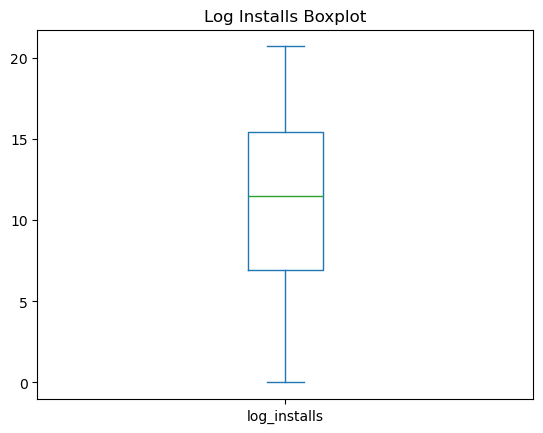

In [184]:
# Fixing the rating column
google_pdf["log_installs"].plot(kind="box")
plt.title("Log Installs Boxplot")
plt.show()

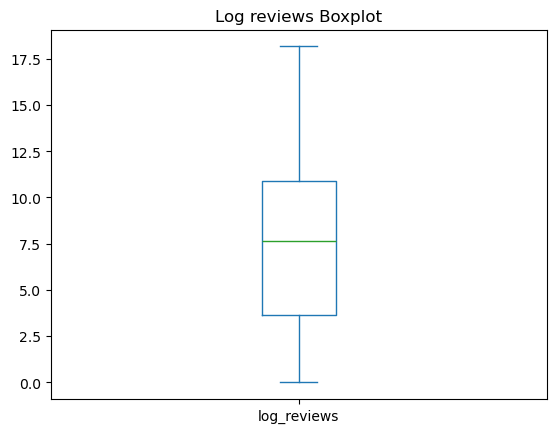

In [185]:
google_pdf["log_reviews"].plot(kind="box")
plt.title("Log reviews Boxplot")
plt.show()

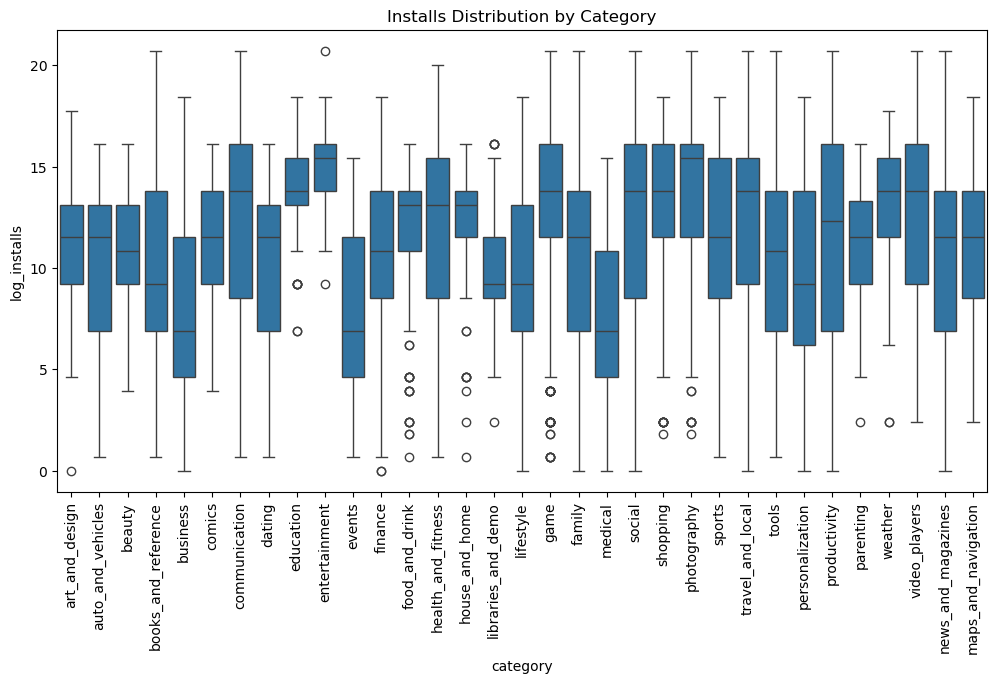

In [186]:
#showing distribution differences across categories
plt.figure(figsize=(12,6))

sns.boxplot(
    data=google_pdf,
    x="category",
    y="log_installs"
)

plt.xticks(rotation=90)
plt.title("Installs Distribution by Category")
plt.show()

In [187]:
google_pdf.to_csv("google_play_store_cleaned.csv", index=False)

#### Visualization showing the relationship between different apps on Tableau Public: 
https://public.tableau.com/app/profile/millicent.onchari/viz/GoogleAppAnalysisVisualizations/Dashboard1?publish=yes

### Conclusion

The dataset has been successfully cleaned and standardized. It is now in a reliable state for exploratory data analysis and insight generation.

This ensures that any conclusions drawn from the data will be based on accurate, consistent, and well-structured information.

In [188]:
spark.stop()